<a href="https://colab.research.google.com/github/financial1A/ML/blob/main/NDXvPREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching 1 month of hourly data for ^NDX...


/tmp/ipykernel_628/1156680287.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1mo", interval="1h")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training model on historical data...
Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.2286
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0561
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0597
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0393
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0313
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0356
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0321
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0227
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0264
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0265
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0231
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0228
Epoch 13/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0216
Epoch 14/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0230
Epoch 15/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.02

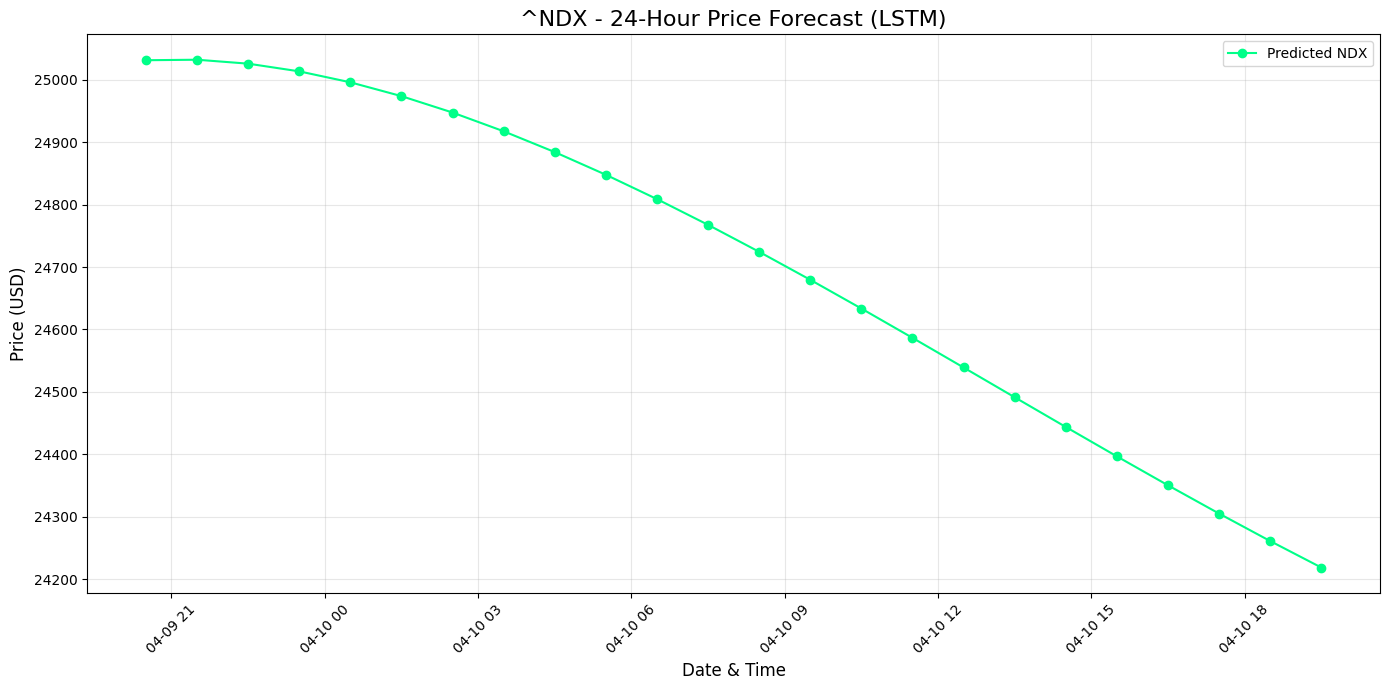

Predicted price at 2026-04-10 19:30:00+00:00: $24218.44


In [1]:
# 1. Install necessary library
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from datetime import datetime, timedelta

# --- 1. DATA FETCHING ---
# Symbol for Nasdaq-100 is ^NDX
ticker = "^NDX"
print(f"Fetching 1 month of hourly data for {ticker}...")

# yfinance allows '1h' interval for up to 2 years
# We fetch '1mo' to get exactly 1 month of historical data
df = yf.download(ticker, period="1mo", interval="1h")

# Ensure we only have the 'Close' prices
data_raw = df['Close'].values.reshape(-1, 1)

# --- 2. PREPROCESSING ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_raw)

# Using the last 60 hours to predict the next 1
SEQ_LENGTH = 60

def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(x), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LENGTH)

# --- 3. MODEL ARCHITECTURE ---
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# --- 4. TRAINING ---
print("Training model on historical data...")
model.fit(X, y, batch_size=32, epochs=25, verbose=1)

# --- 5. RECURSIVE 24-HOUR PREDICTION ---
# Get the most recent window of data
last_window = scaled_data[-SEQ_LENGTH:]
future_predictions = []
current_batch = last_window.reshape((1, SEQ_LENGTH, 1))

for i in range(24):
    # Predict the next hour
    current_pred = model.predict(current_batch, verbose=0)[0]
    future_predictions.append(current_pred)

    # Update the batch: Slide window forward by adding the prediction
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

# Inverse transform to get actual price levels
forecast_prices = scaler.inverse_transform(future_predictions)

# --- 6. VISUALIZATION ---
# Create timestamps for the next 24 hours
last_date = df.index[-1]
prediction_dates = [last_date + timedelta(hours=i) for i in range(1, 25)]

plt.figure(figsize=(14, 7))
plt.plot(prediction_dates, forecast_prices, color='#00ff88', marker='o', label='Predicted NDX')

plt.title(f'{ticker} - 24-Hour Price Forecast (LSTM)', fontsize=16)
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Print the predicted price for exactly 24 hours from now
print(f"Predicted price at {prediction_dates[-1]}: ${forecast_prices[-1][0]:.2f}")